In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:/Users/dobby/Downloads/openweather_weather_airpollution_top3cities_per_country.csv")

# The features we'll use for regression
FEATURES = ['temp', 'humidity', 'pressure', 'wind_speed', 'clouds_all', 'no2', 'o3', 'co']
TARGET   = 'target_pm25'

# Keep only relevant columns, drop any missing rows
data = df[FEATURES + [TARGET]].dropna()

print("Shape:", data.shape)
print("\nFirst 5 rows:")
print(data.head())

print("\nBasic stats:")
print(data.describe().round(2))

Shape: (583, 9)

First 5 rows:
    temp  humidity  pressure  wind_speed  clouds_all    no2      o3      co  \
0  14.11        75      1020        0.45          69   6.88   66.71  135.40   
1  14.33        75      1020        0.45          69   6.88   66.71  135.40   
2  35.84        24      1009        3.09           8  14.91   90.17  187.29   
3  33.02        38      1010        3.60           0   0.73  109.45  113.88   
4  36.00        24      1010        3.60           0  14.42   93.22  182.82   

   target_pm25  
0         4.71  
1         4.71  
2        28.41  
3        18.07  
4        31.45  

Basic stats:
         temp  humidity  pressure  wind_speed  clouds_all     no2      o3  \
count  583.00    583.00    583.00      583.00      583.00  583.00  583.00   
mean    20.66     67.03   1013.11        3.31       48.91    3.03   62.58   
std      8.02     21.94      5.00        2.14       40.97    6.74   37.85   
min     -0.65      1.00    998.00        0.00        0.00    0.01    1

=== Simple Linear Regression: humidity → PM2.5 ===
  b₀ (intercept) = 28.9846
  b₁ (slope)     = -0.2823
  Equation: PM2.5 = 28.98 + -0.2823 × humidity
  r (Pearson)    = -0.3815
  p-value        = 1.2258e-21

=== Metrics ===
  R²   = 0.1456  ← explains 14.6% of variance in PM2.5
  MSE  = 224.8400  ← average squared error
  RMSE = 14.9947 ← average error in µg/m³ (same unit as PM2.5)
  MAE  = 8.8287  ← average absolute error in µg/m³


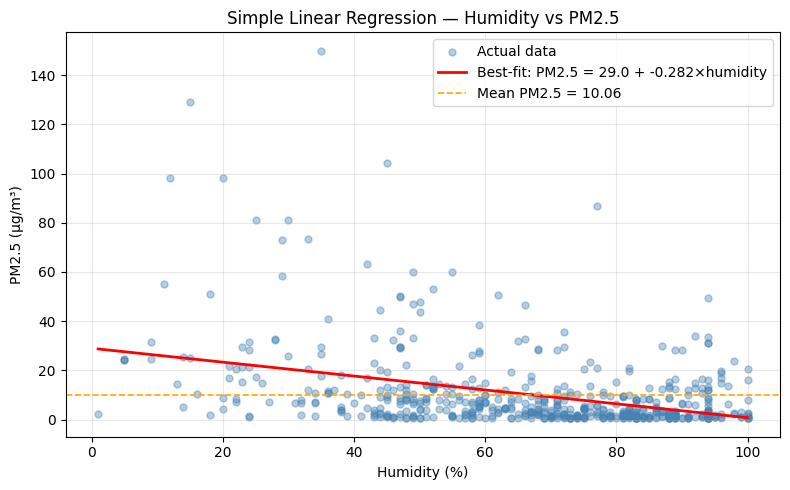

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from scipy import stats

df = pd.read_csv("C:/Users/dobby/Downloads/openweather_weather_airpollution_top3cities_per_country.csv")
FEATURES = ['temp', 'humidity', 'pressure', 'wind_speed', 'clouds_all', 'no2', 'o3', 'co']
TARGET = 'target_pm25'
data = df[FEATURES + [TARGET]].dropna()

# ── Pick one feature ──────────────────────────────────────
feature = 'humidity'
x = data[feature].values
y = data[TARGET].values

# ── Fit with scipy (gives us slope, intercept, r directly) ──
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"=== Simple Linear Regression: {feature} → PM2.5 ===")
print(f"  b₀ (intercept) = {intercept:.4f}")
print(f"  b₁ (slope)     = {slope:.4f}")
print(f"  Equation: PM2.5 = {intercept:.2f} + {slope:.4f} × humidity")
print(f"  r (Pearson)    = {r_value:.4f}")
print(f"  p-value        = {p_value:.4e}")

# ── Predictions & Metrics ─────────────────────────────────
y_pred = intercept + slope * x

r2   = r2_score(y, y_pred)
mse  = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y, y_pred)

print(f"\n=== Metrics ===")
print(f"  R²   = {r2:.4f}  ← explains {r2*100:.1f}% of variance in PM2.5")
print(f"  MSE  = {mse:.4f}  ← average squared error")
print(f"  RMSE = {rmse:.4f} ← average error in µg/m³ (same unit as PM2.5)")
print(f"  MAE  = {mae:.4f}  ← average absolute error in µg/m³")

# ── Plot ──────────────────────────────────────────────────
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, color='steelblue', label='Actual data', s=25)
plt.plot(x_line, y_line, color='red', lw=2, label=f'Best-fit: PM2.5 = {intercept:.1f} + {slope:.3f}×humidity')
plt.axhline(y.mean(), color='orange', lw=1.2, ls='--', label=f'Mean PM2.5 = {y.mean():.2f}')
plt.xlabel('Humidity (%)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Simple Linear Regression — Humidity vs PM2.5')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

=== Simple Linear Regression: no2 → PM2.5 ===
  b₀ (intercept) = 7.8955
  b₁ (slope)     = 0.7147
  Equation: PM2.5 = 7.90 + 0.7147 × no2
  r (Pearson)    = 0.2967
  p-value        = 2.6027e-13

=== Metrics ===
  R²   = 0.0880  ← explains 8.8% of variance in PM2.5
  MSE  = 239.9787  ← average squared error
  RMSE = 15.4912 ← average error in µg/m³ (same unit as PM2.5)
  MAE  = 8.7486  ← average absolute error in µg/m³


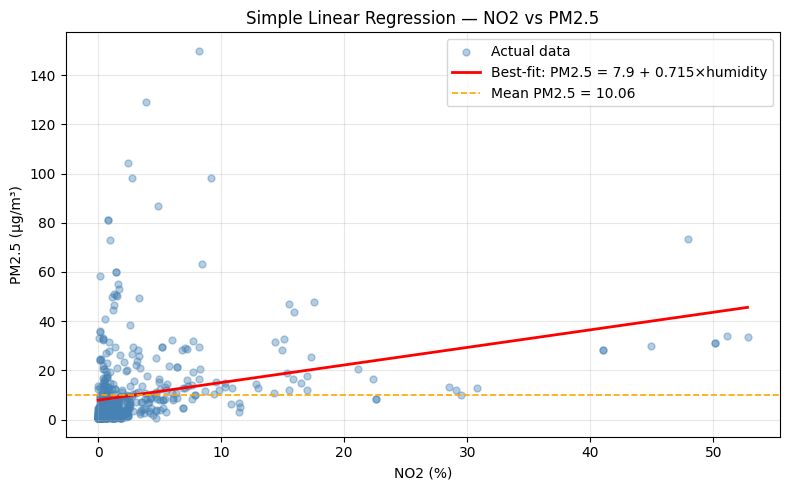

In [4]:
# ── Pick one feature ──────────────────────────────────────
feature = 'no2'
x = data[feature].values
y = data[TARGET].values

# ── Fit with scipy (gives us slope, intercept, r directly) ──
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

print(f"=== Simple Linear Regression: {feature} → PM2.5 ===")
print(f"  b₀ (intercept) = {intercept:.4f}")
print(f"  b₁ (slope)     = {slope:.4f}")
print(f"  Equation: PM2.5 = {intercept:.2f} + {slope:.4f} × no2")
print(f"  r (Pearson)    = {r_value:.4f}")
print(f"  p-value        = {p_value:.4e}")

# ── Predictions & Metrics ─────────────────────────────────
y_pred = intercept + slope * x

r2   = r2_score(y, y_pred)
mse  = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae  = mean_absolute_error(y, y_pred)

print(f"\n=== Metrics ===")
print(f"  R²   = {r2:.4f}  ← explains {r2*100:.1f}% of variance in PM2.5")
print(f"  MSE  = {mse:.4f}  ← average squared error")
print(f"  RMSE = {rmse:.4f} ← average error in µg/m³ (same unit as PM2.5)")
print(f"  MAE  = {mae:.4f}  ← average absolute error in µg/m³")

# ── Plot ──────────────────────────────────────────────────
x_line = np.linspace(x.min(), x.max(), 200)
y_line = intercept + slope * x_line

plt.figure(figsize=(8, 5))
plt.scatter(x, y, alpha=0.4, color='steelblue', label='Actual data', s=25)
plt.plot(x_line, y_line, color='red', lw=2, label=f'Best-fit: PM2.5 = {intercept:.1f} + {slope:.3f}×humidity')
plt.axhline(y.mean(), color='orange', lw=1.2, ls='--', label=f'Mean PM2.5 = {y.mean():.2f}')
plt.xlabel('NO2 (%)')
plt.ylabel('PM2.5 (µg/m³)')
plt.title('Simple Linear Regression — NO2 vs PM2.5')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
from scipy.stats import pearsonr

print("Pearson r with PM2.5:\n")
for feat in FEATURES:
    r, p = pearsonr(data[feat], data[TARGET])
    bar = '█' * int(abs(r) * 20)
    direction = '+' if r > 0 else '-'
    print(f"  {feat:<12}  r = {r:+.3f}  {direction}{bar}")

Pearson r with PM2.5:

  temp          r = +0.261  +█████
  humidity      r = -0.382  -███████
  pressure      r = -0.186  -███
  wind_speed    r = +0.028  +
  clouds_all    r = -0.111  -██
  no2           r = +0.297  +█████
  o3            r = +0.492  +█████████
  co            r = +0.665  +█████████████


In [7]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


FEATURES = ['temp', 'humidity', 'pressure', 'wind_speed', 'clouds_all', 'no2', 'o3', 'co']
TARGET = 'target_pm25'
data = df[FEATURES + [TARGET]].dropna()

X = data[FEATURES].values
y = data[TARGET].values

# statsmodels needs you to manually add the intercept column (b₀)
X_const = sm.add_constant(X)

# Fit the model
model = sm.OLS(y, X_const).fit()

# Print the full summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.636
Model:                            OLS   Adj. R-squared:                  0.631
Method:                 Least Squares   F-statistic:                     125.3
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          1.28e-120
Time:                        20:25:55   Log-Likelihood:                -2157.2
No. Observations:                 583   AIC:                             4332.
Df Residuals:                     574   BIC:                             4372.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       -177.4286    108.388     -1.637      0.1

In [8]:
# Predictions from the multiple regression model
y_pred = model.predict(X_const)

r2   = r2_score(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))
mae  = mean_absolute_error(y, y_pred)

print(f"\n=== Multiple Regression Metrics ===")
print(f"  R²   = {r2:.4f}  ← all 8 features together explain {r2*100:.1f}% of PM2.5")
print(f"  RMSE = {rmse:.4f} µg/m³")
print(f"  MAE  = {mae:.4f} µg/m³")

print(f"\n=== AIC ===")
print(f"  AIC  = {model.aic:.2f}")
print(f"  BIC  = {model.bic:.2f}")
print(f"\n  (Lower AIC = better fit with less complexity)")


=== Multiple Regression Metrics ===
  R²   = 0.6358  ← all 8 features together explain 63.6% of PM2.5
  RMSE = 9.7890 µg/m³
  MAE  = 6.1757 µg/m³

=== AIC ===
  AIC  = 4332.44
  BIC  = 4371.75

  (Lower AIC = better fit with less complexity)


Mean of residuals: -0.000000
Std  of residuals: 9.7890


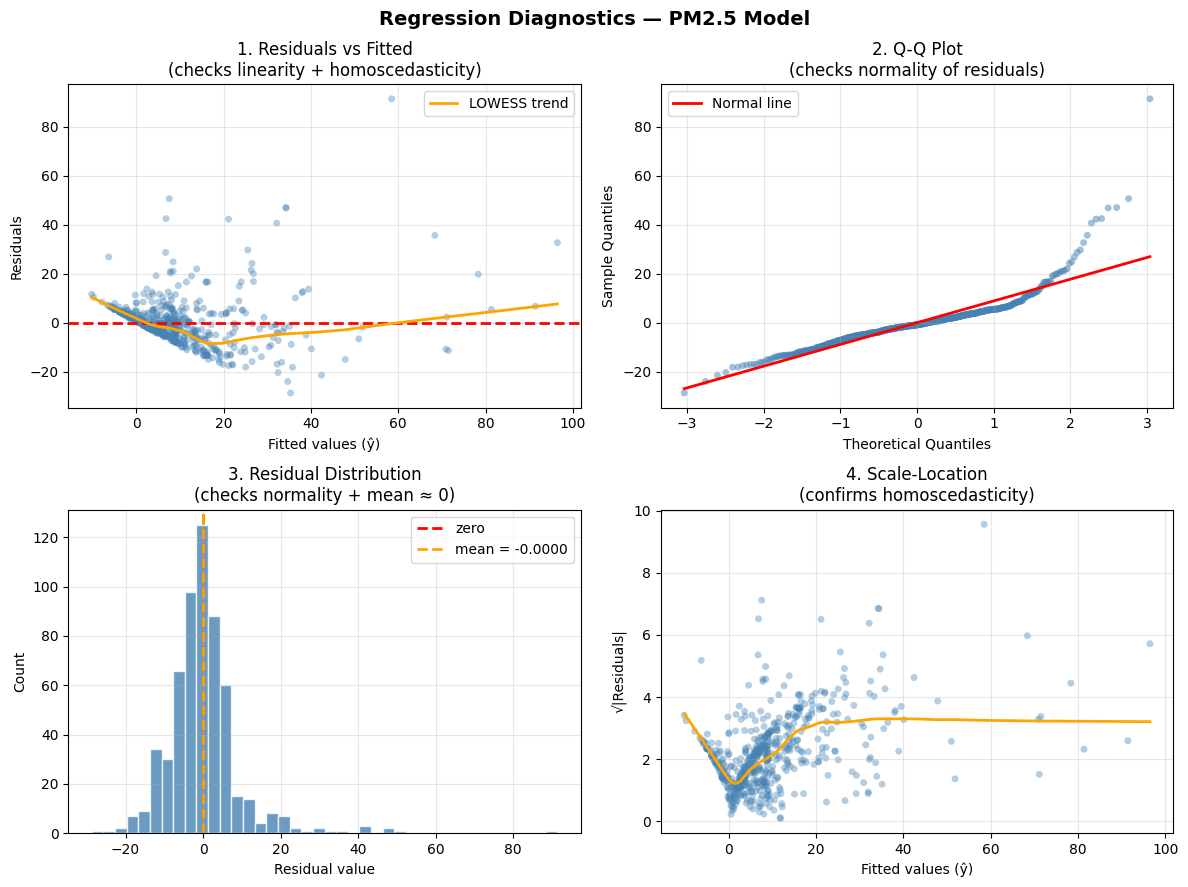

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats


FEATURES = ['temp', 'humidity', 'pressure', 'wind_speed', 'clouds_all', 'no2', 'o3', 'co']
TARGET = 'target_pm25'
data = df[FEATURES + [TARGET]].dropna()

X = data[FEATURES].values
y = data[TARGET].values
X_const = sm.add_constant(X)
model = sm.OLS(y, X_const).fit()

residuals = model.resid        # y - ŷ
y_pred    = model.predict(X_const)  # ŷ

print(f"Mean of residuals: {residuals.mean():.6f}")
print(f"Std  of residuals: {residuals.std():.4f}")

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Regression Diagnostics — PM2.5 Model', fontsize=14, fontweight='bold')

# ── Plot 1: Residuals vs Fitted ──────────────────────────
ax = axes[0, 0]
ax.scatter(y_pred, residuals, alpha=0.4, color='steelblue', s=25, edgecolors='none')
ax.axhline(0, color='red', lw=2, ls='--')
lowess = sm.nonparametric.lowess(residuals, y_pred, frac=0.3)
ax.plot(lowess[:, 0], lowess[:, 1], color='orange', lw=2, label='LOWESS trend')
ax.set_xlabel('Fitted values (ŷ)')
ax.set_ylabel('Residuals')
ax.set_title('1. Residuals vs Fitted\n(checks linearity + homoscedasticity)')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 2: Q-Q Plot ─────────────────────────────────────
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals, dist='norm')
ax.scatter(osm, osr, alpha=0.5, color='steelblue', s=25, edgecolors='none')
ax.plot([osm.min(), osm.max()],
        [slope * osm.min() + intercept, slope * osm.max() + intercept],
        color='red', lw=2, label='Normal line')
ax.set_xlabel('Theoretical Quantiles')
ax.set_ylabel('Sample Quantiles')
ax.set_title('2. Q-Q Plot\n(checks normality of residuals)')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 3: Residual Distribution ────────────────────────
ax = axes[1, 0]
ax.hist(residuals, bins=40, color='steelblue', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', lw=2, ls='--', label='zero')
ax.axvline(residuals.mean(), color='orange', lw=2, ls='--',
           label=f'mean = {residuals.mean():.4f}')
ax.set_xlabel('Residual value')
ax.set_ylabel('Count')
ax.set_title('3. Residual Distribution\n(checks normality + mean ≈ 0)')
ax.legend()
ax.grid(alpha=0.3)

# ── Plot 4: Scale-Location ───────────────────────────────
ax = axes[1, 1]
sqrt_abs_res = np.sqrt(np.abs(residuals))
ax.scatter(y_pred, sqrt_abs_res, alpha=0.4, color='steelblue', s=25, edgecolors='none')
lowess2 = sm.nonparametric.lowess(sqrt_abs_res, y_pred, frac=0.3)
ax.plot(lowess2[:, 0], lowess2[:, 1], color='orange', lw=2)
ax.set_xlabel('Fitted values (ŷ)')
ax.set_ylabel('√|Residuals|')
ax.set_title('4. Scale-Location\n(confirms homoscedasticity)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.571
Model:                            OLS   Adj. R-squared:                  0.565
Method:                 Least Squares   F-statistic:                     95.68
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          1.81e-100
Time:                        21:00:13   Log-Likelihood:                -604.04
No. Observations:                 583   AIC:                             1226.
Df Residuals:                     574   BIC:                             1265.
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -17.7355      7.551     -2.349      0.0

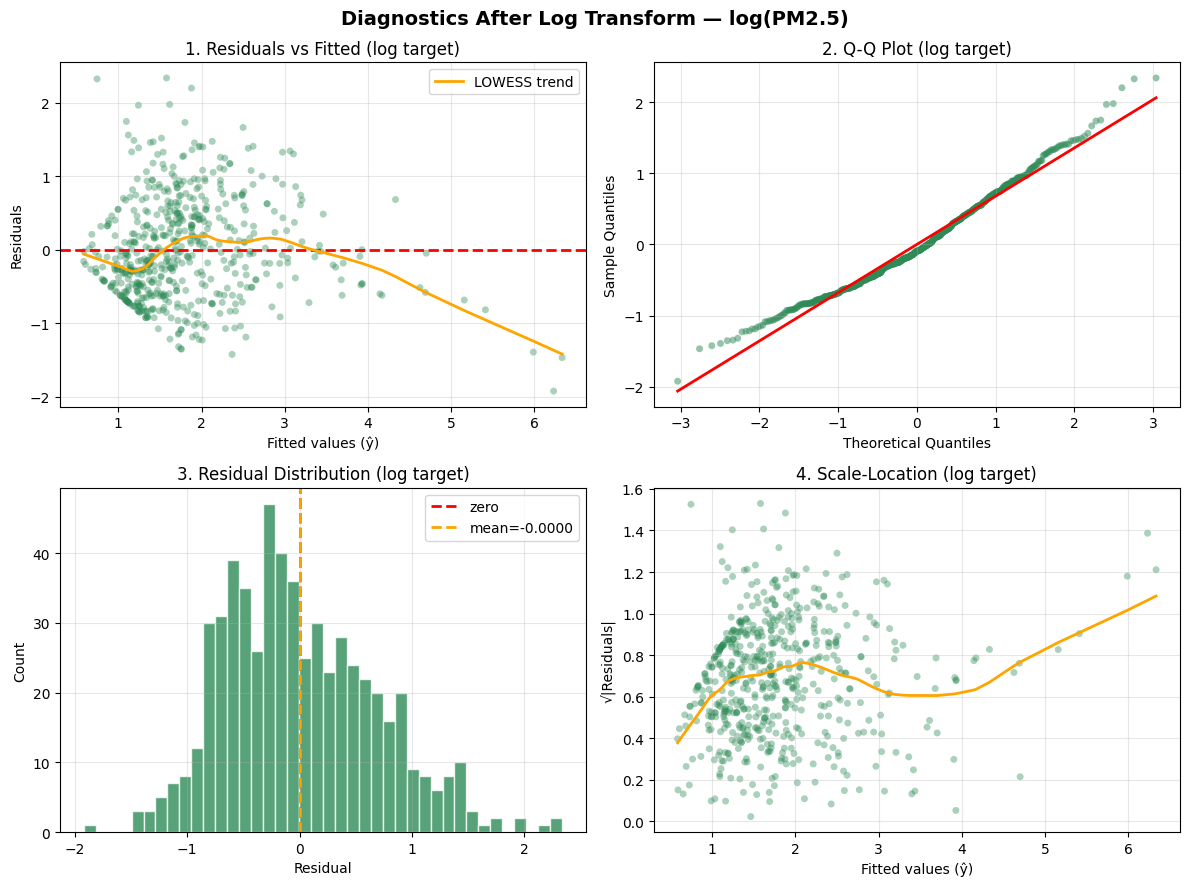

In [10]:
import numpy as np

# Add log-transformed target
data = data.copy()
data['log_pm25'] = np.log(data['target_pm25'] + 1)  # +1 avoids log(0)

X = data[FEATURES].values
y_log = data['log_pm25'].values
X_const = sm.add_constant(X)

model_log = sm.OLS(y_log, X_const).fit()
print(model_log.summary())

# Check residuals again
residuals_log = model_log.resid
y_pred_log    = model_log.predict(X_const)

print(f"\nMean of residuals: {residuals_log.mean():.6f}")

# Plot the same 4 diagostics again
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle('Diagnostics After Log Transform — log(PM2.5)', fontsize=14, fontweight='bold')

# Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(y_pred_log, residuals_log, alpha=0.4, color='seagreen', s=25, edgecolors='none')
ax.axhline(0, color='red', lw=2, ls='--')
lowess = sm.nonparametric.lowess(residuals_log, y_pred_log, frac=0.3)
ax.plot(lowess[:, 0], lowess[:, 1], color='orange', lw=2, label='LOWESS trend')
ax.set_xlabel('Fitted values (ŷ)'); ax.set_ylabel('Residuals')
ax.set_title('1. Residuals vs Fitted (log target)')
ax.legend(); ax.grid(alpha=0.3)

# Q-Q
ax = axes[0, 1]
(osm, osr), (slope, intercept, r) = stats.probplot(residuals_log, dist='norm')
ax.scatter(osm, osr, alpha=0.5, color='seagreen', s=25, edgecolors='none')
ax.plot([osm.min(), osm.max()],
        [slope * osm.min() + intercept, slope * osm.max() + intercept],
        color='red', lw=2)
ax.set_xlabel('Theoretical Quantiles'); ax.set_ylabel('Sample Quantiles')
ax.set_title('2. Q-Q Plot (log target)')
ax.grid(alpha=0.3)

# Histogram
ax = axes[1, 0]
ax.hist(residuals_log, bins=40, color='seagreen', edgecolor='white', alpha=0.8)
ax.axvline(0, color='red', lw=2, ls='--', label='zero')
ax.axvline(residuals_log.mean(), color='orange', lw=2, ls='--',
           label=f'mean={residuals_log.mean():.4f}')
ax.set_xlabel('Residual'); ax.set_ylabel('Count')
ax.set_title('3. Residual Distribution (log target)')
ax.legend(); ax.grid(alpha=0.3)

# Scale-Location
ax = axes[1, 1]
sqrt_abs = np.sqrt(np.abs(residuals_log))
ax.scatter(y_pred_log, sqrt_abs, alpha=0.4, color='seagreen', s=25, edgecolors='none')
lowess2 = sm.nonparametric.lowess(sqrt_abs, y_pred_log, frac=0.3)
ax.plot(lowess2[:, 0], lowess2[:, 1], color='orange', lw=2)
ax.set_xlabel('Fitted values (ŷ)'); ax.set_ylabel('√|Residuals|')
ax.set_title('4. Scale-Location (log target)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

=== VIF Scores ===

  pressure      VIF =   55.05  ❌ DROP  ██████████████████████████████
  humidity      VIF =   17.69  ❌ DROP  █████████████████
  temp          VIF =    9.83  ⚠️  CHECK  █████████
  o3            VIF =    6.60  ⚠️  CHECK  ██████
  co            VIF =    5.27  ⚠️  CHECK  █████
  wind_speed    VIF =    3.57  ✅ OK  ███
  clouds_all    VIF =    2.68  ✅ OK  ██
  no2           VIF =    1.88  ✅ OK  █


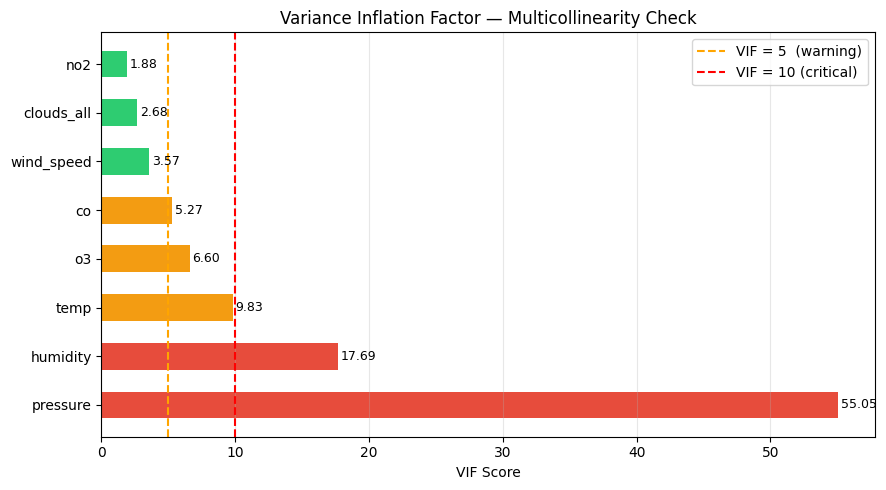

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


FEATURES = ['temp', 'humidity', 'pressure', 'wind_speed', 'clouds_all', 'no2', 'o3', 'co']
TARGET = 'target_pm25'
data = df[FEATURES + [TARGET]].dropna()

X = data[FEATURES].values
y = data[TARGET].values

# ── Calculate VIF for each feature ───────────────────────
vif_df = pd.DataFrame()
vif_df['Feature'] = FEATURES
vif_df['VIF']     = [variance_inflation_factor(X, i) for i in range(X.shape[1])]
vif_df = vif_df.sort_values('VIF', ascending=False)

print("=== VIF Scores ===\n")
for _, row in vif_df.iterrows():
    flag  = '❌ DROP'    if row['VIF'] > 10 else \
            '⚠️  CHECK'  if row['VIF'] > 5  else '✅ OK'
    bar   = '█' * int(min(row['VIF'], 30))
    print(f"  {row['Feature']:<12}  VIF = {row['VIF']:>7.2f}  {flag}  {bar}")

# ── Plot VIF ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e74c3c' if v > 10 else '#f39c12' if v > 5 else '#2ecc71'
          for v in vif_df['VIF']]
bars = ax.barh(vif_df['Feature'], vif_df['VIF'], color=colors, edgecolor='none', height=0.55)
ax.axvline(5,  color='orange', lw=1.5, ls='--', label='VIF = 5  (warning)')
ax.axvline(10, color='red',    lw=1.5, ls='--', label='VIF = 10 (critical)')
for bar, v in zip(bars, vif_df['VIF']):
    ax.text(v + 0.2, bar.get_y() + bar.get_height()/2,
            f'{v:.2f}', va='center', fontsize=9)
ax.set_xlabel('VIF Score')
ax.set_title('Variance Inflation Factor — Multicollinearity Check')
ax.legend()
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

In [13]:
# Drop features with VIF > 10 and refit
# (wait to see your scores first — but likely pressure and temp)

FEATURES_CLEAN = [f for f in FEATURES
                  if vif_df.set_index('Feature').loc[f, 'VIF'] < 10]

print(f"\nFeatures kept: {FEATURES_CLEAN}")

data['log_pm25'] = np.log(data[TARGET] + 1)
X_clean   = data[FEATURES_CLEAN].values
y_log     = data['log_pm25'].values
X_const   = sm.add_constant(X_clean)

model_clean = sm.OLS(y_log, X_const).fit()
print(model_clean.summary())

print(f"\n=== Comparison ===")
print(f"  Old AIC  (8 features):  1226")
print(f"  New AIC  ({len(FEATURES_CLEAN)} features):  {model_clean.aic:.2f}")
print(f"  Old R²   (8 features):  0.571")
print(f"  New R²   ({len(FEATURES_CLEAN)} features):  {model_clean.rsquared:.3f}")


Features kept: ['temp', 'wind_speed', 'clouds_all', 'no2', 'o3', 'co']
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.561
Model:                            OLS   Adj. R-squared:                  0.556
Method:                 Least Squares   F-statistic:                     122.5
Date:                Sat, 25 Apr 2026   Prob (F-statistic):           1.88e-99
Time:                        21:50:44   Log-Likelihood:                -611.37
No. Observations:                 583   AIC:                             1237.
Df Residuals:                     576   BIC:                             1267.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------

In [16]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor


TARGET = 'target_pm25'

# Drop the two high VIF features
FEATURES_CLEAN = ['temp', 'clouds_all', 'no2', 'o3', 'co']  

data = df[FEATURES_CLEAN + [TARGET]].dropna()
data['log_pm25'] = np.log(data[TARGET] + 1)

X_clean = data[FEATURES_CLEAN].values
y_log   = data['log_pm25'].values

# ── Recheck VIF after dropping ────────────────────────────
print("=== VIF After Dropping pressure + humidity ===\n")
for i, feat in enumerate(FEATURES_CLEAN):
    vif = variance_inflation_factor(X_clean, i)
    flag = '❌' if vif > 10 else '⚠️ ' if vif > 5 else '✅'
    bar  = '█' * int(min(vif, 30))
    print(f"  {feat:<12}  VIF = {vif:>6.2f}  {flag}  {bar}")

# ── Refit model ───────────────────────────────────────────
X_const = sm.add_constant(X_clean)
model_clean = sm.OLS(y_log, X_const).fit()
print(model_clean.summary())

=== VIF After Dropping pressure + humidity ===

  temp          VIF =   4.30  ✅  ████
  clouds_all    VIF =   2.09  ✅  ██
  no2           VIF =   1.80  ✅  █
  o3            VIF =   3.09  ✅  ███
  co            VIF =   5.17  ⚠️   █████
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.559
Model:                            OLS   Adj. R-squared:                  0.555
Method:                 Least Squares   F-statistic:                     146.4
Date:                Sat, 25 Apr 2026   Prob (F-statistic):          3.72e-100
Time:                        21:57:21   Log-Likelihood:                -612.30
No. Observations:                 583   AIC:                             1237.
Df Residuals:                     577   BIC:                             1263.
Df Model:                           5                                         
Covariance Type:            nonrobust                 